In [ ]:
from google.colab import drive
import os
import torch

drive.mount('/content/drive')

if not os.path.exists('/content/organized_places365/train_samples'):
    !unzip -q "/content/drive/MyDrive/Scene Classification/organized_places365.zip" -d "/content/organized_places365"
    print("Extraction complete!")
else:
    print("Dataset already extracted")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Extraction complete!
Using device: cuda


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_data = datasets.ImageFolder('/content/organized_places365/train_samples', transform=train_transform)
valid_data = datasets.ImageFolder('/content/organized_places365/valid_samples', transform=eval_transform)
test_data = datasets.ImageFolder('/content/organized_places365/test_samples', transform=eval_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Loaded {len(train_data)} Train, {len(valid_data)} Valid, and {len(test_data)} Test images.")

Loaded 21900 Train, 7298 Valid, and 7302 Test images.


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

class MobileNetSceneClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freezing the ENTIRE CNN backbone first
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Unfreezing the last 5 blocks (indices 14 through 18) for fine-tuning
        for param in self.model.features[14:].parameters():
            param.requires_grad = True

        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Move to GPU
model = MobileNetSceneClassifier(num_classes=len(train_data.classes)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001, weight_decay=0.05)

print("Fine-Tuning MobileNetV2 successfully built")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]


Fine-Tuning MobileNetV2 successfully built


In [ ]:
import time

MAX_EPOCHS = 15
PATIENCE = 4
epochs_without_improvement = 0
best_accuracy = 0.0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

print(f"Starting...\n")

Starting...



In [ ]:
for epoch in range(MAX_EPOCHS):
    start_time = time.time()

    # --- TRAIN ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # --- VALIDATE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # --- PRINT STATS ---
    print(f"EPOCH {epoch+1} ({time.time() - start_time:.0f}s)")
    print(f"Train Loss: {train_loss/train_total:.4f} | Acc: {(train_correct/train_total)*100:.2f}%")
    val_acc = (val_correct/val_total)*100
    print(f"Val Loss:   {val_loss/val_total:.4f} | Acc: {val_acc:.2f}%")

    # --- EARLY STOPPING ---
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/Scene Classification/mobilenet_scene_classifier-3.pth")
        print("New best! Saved weights.")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("\nEarly Stopping Applied!")
            break
    print("-" * 30)

    scheduler.step()

EPOCH 1 (150s)
Train Loss: 4.8386 | Acc: 12.50%
Val Loss:   3.9920 | Acc: 19.35%
New best! Saved weights.
------------------------------
EPOCH 2 (148s)
Train Loss: 3.9711 | Acc: 20.49%
Val Loss:   3.5610 | Acc: 26.56%
New best! Saved weights.
------------------------------
EPOCH 3 (151s)
Train Loss: 3.6256 | Acc: 26.42%
Val Loss:   3.3946 | Acc: 30.21%
New best! Saved weights.
------------------------------
EPOCH 4 (146s)
Train Loss: 3.4243 | Acc: 30.38%
Val Loss:   3.2804 | Acc: 32.68%
New best! Saved weights.
------------------------------
EPOCH 5 (148s)
Train Loss: 3.2748 | Acc: 33.88%
Val Loss:   3.2194 | Acc: 34.39%
New best! Saved weights.
------------------------------
EPOCH 6 (150s)
Train Loss: 3.1581 | Acc: 36.89%
Val Loss:   3.1847 | Acc: 34.97%
New best! Saved weights.
------------------------------
EPOCH 7 (148s)
Train Loss: 3.0548 | Acc: 39.45%
Val Loss:   3.1613 | Acc: 35.50%
New best! Saved weights.
------------------------------
EPOCH 8 (147s)
Train Loss: 2.9636 | Acc: 

In [ ]:
model = MobileNetSceneClassifier(num_classes=len(train_data.classes)).to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/Scene Classification/mobilenet_scene_classifier-final.pth', map_location=device))

model.eval()
print("Saved weights loaded successfully!")

Saved weights loaded successfully!


In [ ]:
top1_correct, top5_correct, total_images = 0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Top-1
        _, predicted = torch.max(outputs, 1)
        top1_correct += (predicted == labels).sum().item()

        # Top-5
        _, top5_preds = torch.topk(outputs, 5, dim=1)
        for i in range(labels.size(0)):
            if labels[i] in top5_preds[i]:
                top5_correct += 1
        total_images += labels.size(0)

print(f"MOBILENET TOP-1 ACCURACY: {(top1_correct / total_images) * 100:.2f}%")
print(f"MOBILENET TOP-5 ACCURACY: {(top5_correct / total_images) * 100:.2f}%")

MOBILENET TOP-1 ACCURACY: 37.72%
MOBILENET TOP-5 ACCURACY: 71.25%


In [ ]:
!pip install -q thop
from thop import profile
import numpy as np

# TOTAL MODEL FLOPs
dummy_image = torch.randn(1, 3, 224, 224).to(device)
macs_total, params_total = profile(model, inputs=(dummy_image, ), verbose=False)
print(f"\nTotal Model: {params_total:,} parameters | {(macs_total * 2) / 1e9:.3f} GFLOPs")

# LATENCY
with torch.no_grad():
    for _ in range(50): _ = model(dummy_image)

latencies = []
with torch.no_grad():
    for _ in range(100):
        torch.cuda.synchronize()
        start = time.time()
        _ = model(dummy_image)
        torch.cuda.synchronize()
        latencies.append((time.time() - start) * 1000)

print(f"Average Latency: {np.mean(latencies):.2f} ms per image")


Total Model: 2,626,106.0 parameters | 0.653 GFLOPs
Average Latency: 6.41 ms per image


Upload an image to classify:


Saving Places365_val_00002782.jpg to Places365_val_00002782 (4).jpg


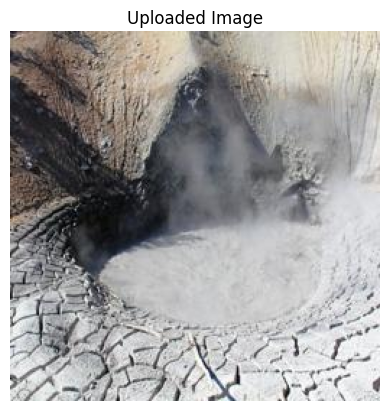


TOP 5 PREDICTIONS
1. hot_spring                 53.98%
2. volcano                    15.67%
3. ice_floe                    4.63%
4. grotto                      3.56%
5. wave                        1.72%


In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

print("Upload an image to classify:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert('RGB')
plt.imshow(image)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

image_tensor = eval_transform(image)
image_tensor = image_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = F.softmax(outputs, dim=1)
    top5_probs, top5_indices = torch.topk(probabilities, 5)

print("\n" + "="*30)
print("TOP 5 PREDICTIONS")
print("="*30)

for i in range(5):
    prob = top5_probs[0][i].item() * 100
    idx = top5_indices[0][i].item()
    class_name = train_data.classes[idx]
    print(f"{i+1}. {class_name: <25} {prob:>6.2f}%")